# Physics-Grounded Self-Supervised Vision (PGSV) — Notebook 1: MNIST

## Overview
This notebook implements the **PGSV framework** on MNIST as a baseline study.  
Goal: learn structured latent representations of digit *objects* without any labels,  
using reconstruction, temporal consistency, and latent prediction losses.

### Architecture pipeline:
```
Image → Encoder (CNN/ViT) → Latent z → Object Slots → Geometry Module
                                                    ↓
                                           Temporal / Dynamics MLP
                                                    ↓
                                           Decoder → Reconstructed Image
```

### Training signals (all self-supervised, no labels):
- **Reconstruction loss** — decoded image should match input
- **Temporal consistency** — latents from consecutive augmented views should be close
- **Latent prediction loss** — dynamics MLP predicts next latent from current one
- **Contrastive loss** — positive pairs (same digit under augmentation) pulled together

### Experiments:
1. Baseline VAE (no physics/geometry)
2. PGSV-inspired model (with object slots + temporal dynamics)
3. Comparison plots and evaluation

In [4]:
# ── Install / imports ──────────────────────────────────────────────────────────
!pip install -q einops umap-learn

import os, math, random, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from einops import rearrange, repeat

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Running on: {DEVICE}')
torch.manual_seed(42)
np.random.seed(42)

Running on: cuda


## 1. Dataset — Augmented MNIST Pairs
We construct **paired samples**: each MNIST image is augmented twice to form a temporal-like  
pair `(x_t, x_{t+1})`. This simulates sequential observations and enables temporal consistency training.

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.76MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.86MB/s]

Train samples: 60000 | Val samples: 10000


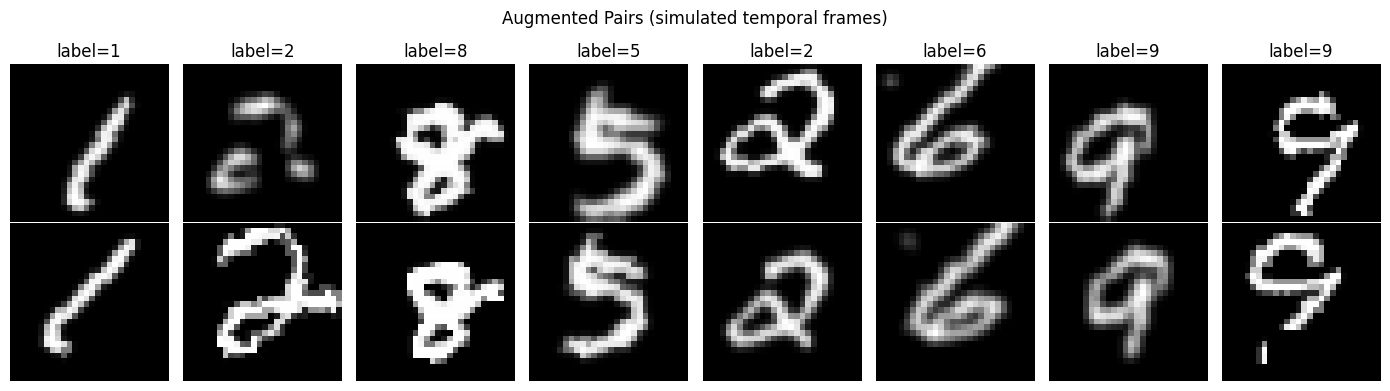

In [5]:
# ── Augmented Pair Dataset ─────────────────────────────────────────────────────
class MNISTPairDataset(Dataset):
    """
    Returns (x_t, x_t1, label) where x_t and x_t1 are two augmented
    views of the same digit — simulating consecutive 'frames'.
    Label is provided only for evaluation, never used in training.
    """
    def __init__(self, root='./data', train=True):
        self.base = torchvision.datasets.MNIST(
            root=root, train=train, download=True,
            transform=T.ToTensor()
        )
        # Strong augmentation simulating camera/viewpoint change
        self.aug = T.Compose([
            T.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.85, 1.15)),
            T.RandomErasing(p=0.3, scale=(0.02, 0.1)),
            T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
        ])

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]          # img: [1, 28, 28]
        x_t  = self.aug(img)                  # augmented view 1 → 'time t'
        x_t1 = self.aug(img)                  # augmented view 2 → 'time t+1'
        return x_t, x_t1, label


# ── Dataloaders ────────────────────────────────────────────────────────────────
BATCH = 256
train_ds = MNISTPairDataset(train=True)
val_ds   = MNISTPairDataset(train=False)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train samples: {len(train_ds)} | Val samples: {len(val_ds)}')

# Quick sanity visualisation
x_t, x_t1, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(x_t[i].squeeze(), cmap='gray'); axes[0, i].set_title(f'label={labels[i].item()}'); axes[0, i].axis('off')
    axes[1, i].imshow(x_t1[i].squeeze(), cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_ylabel('x_t',  fontsize=10)
axes[1, 0].set_ylabel('x_t+1', fontsize=10)
plt.suptitle('Augmented Pairs (simulated temporal frames)', fontsize=12)
plt.tight_layout(); plt.show()

## 2. Model Architecture

### 2a. Encoder — CNN backbone
Produces a global latent vector `z` from input image.

In [6]:
# ── Encoder: CNN → latent vector ───────────────────────────────────────────────
class CNNEncoder(nn.Module):
    """
    4-layer CNN encoder with residual connections.
    Output: mean and log-variance for reparameterisation (VAE-style).
    """
    def __init__(self, in_channels=1, latent_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            # Block 1: 28x28 → 14x14
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.GELU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.GELU(),
            nn.MaxPool2d(2),
            # Block 2: 14x14 → 7x7
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(),
            nn.MaxPool2d(2),
            # Block 3: 7x7 → 3x3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.GELU(),
            nn.AdaptiveAvgPool2d(3),
        )
        feat_dim = 128 * 3 * 3
        self.fc_mu  = nn.Linear(feat_dim, latent_dim)
        self.fc_var = nn.Linear(feat_dim, latent_dim)

    def forward(self, x):
        h = self.net(x).flatten(1)
        return self.fc_mu(h), self.fc_var(h)          # (B, D), (B, D)


def reparameterise(mu, log_var):
    """Reparameterisation trick: z = mu + eps * std."""
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    return mu + eps * std

### 2b. Object-Centric Slot Attention Module
Decomposes the latent into K object slots via competitive attention.

In [7]:
# ── Slot Attention (simplified) ───────────────────────────────────────────────
class SlotAttention(nn.Module):
    """
    Simplified Slot Attention (Locatello et al., 2020).
    Maps a set of feature vectors to K competing object slots.

    Args:
        num_slots  : number of object slots K
        slot_dim   : dimensionality of each slot
        num_iters  : attention refinement iterations
    """
    def __init__(self, num_slots=4, slot_dim=32, num_iters=3, input_dim=64):
        super().__init__()
        self.num_slots = num_slots
        self.slot_dim  = slot_dim
        self.num_iters = num_iters
        self.scale     = slot_dim ** -0.5

        # Slot initialisation parameters (learnable)
        self.slots_mu    = nn.Parameter(torch.randn(1, 1, slot_dim))
        self.slots_sigma = nn.Parameter(torch.ones(1, 1, slot_dim))

        # Projection layers
        self.to_q = nn.Linear(slot_dim, slot_dim, bias=False)
        self.to_k = nn.Linear(input_dim, slot_dim, bias=False)
        self.to_v = nn.Linear(input_dim, slot_dim, bias=False)

        # GRU-based slot update
        self.gru     = nn.GRUCell(slot_dim, slot_dim)
        self.norm_in = nn.LayerNorm(input_dim)
        self.norm_sl = nn.LayerNorm(slot_dim)

        # Slot-wise MLP for nonlinear refinement
        self.mlp = nn.Sequential(
            nn.LayerNorm(slot_dim),
            nn.Linear(slot_dim, slot_dim * 2),
            nn.GELU(),
            nn.Linear(slot_dim * 2, slot_dim)
        )

    def forward(self, inputs):
        """
        inputs: (B, N, input_dim)  — N feature tokens
        returns slots: (B, K, slot_dim)
        """
        B, N, _ = inputs.shape
        inputs = self.norm_in(inputs)

        # Initialise slots from learnable Gaussian
        mu    = self.slots_mu.expand(B, self.num_slots, -1)
        sigma = self.slots_sigma.expand(B, self.num_slots, -1).abs() + 1e-5
        slots = mu + sigma * torch.randn_like(mu)

        k = self.to_k(inputs)   # (B, N, D)
        v = self.to_v(inputs)   # (B, N, D)

        for _ in range(self.num_iters):
            slots_prev = slots
            q = self.to_q(self.norm_sl(slots))                  # (B, K, D)
            attn = torch.einsum('bkd,bnd->bkn', q, k) * self.scale  # (B, K, N)
            attn = F.softmax(attn, dim=1)                        # compete over slots
            attn = attn / (attn.sum(dim=-1, keepdim=True) + 1e-8)  # normalise
            updates = torch.einsum('bkn,bnd->bkd', attn, v)     # (B, K, D)
            # Update each slot independently via shared GRU
            slots = self.gru(
                updates.reshape(B * self.num_slots, self.slot_dim),
                slots_prev.reshape(B * self.num_slots, self.slot_dim)
            ).reshape(B, self.num_slots, self.slot_dim)
            slots = slots + self.mlp(slots)

        return slots   # (B, K, slot_dim)

### 2c. Geometry Module
Learns a per-slot spatial position and depth estimate, enforcing spatial consistency.

In [8]:
# ── Geometry / Perspective Module ─────────────────────────────────────────────
class GeometryModule(nn.Module):
    """
    Estimates per-slot (x, y, depth) from object slots.
    Applies a soft perspective projection to enforce geometry consistency.

    The projection follows: u = f*X/Z, v = f*Y/Z
    where (X,Y,Z) is 3D position and f is focal length (learnable).
    """
    def __init__(self, slot_dim=32):
        super().__init__()
        # Predict (x, y, log_depth) per slot
        self.pose_head = nn.Sequential(
            nn.Linear(slot_dim, 64), nn.GELU(),
            nn.Linear(64, 3)          # (x, y, log_depth)
        )
        self.log_focal = nn.Parameter(torch.zeros(1))   # learnable focal length

    def forward(self, slots):
        """
        slots: (B, K, slot_dim)
        returns:
            poses:      (B, K, 3)  — (x, y, depth)
            projected:  (B, K, 2)  — 2D image-plane coordinates
        """
        raw   = self.pose_head(slots)                # (B, K, 3)
        x, y  = raw[..., 0], raw[..., 1]
        depth = torch.exp(raw[..., 2]) + 1e-3        # positive depth

        f     = torch.exp(self.log_focal)            # positive focal length
        u     = f * x / depth                        # perspective projection
        v     = f * y / depth

        poses     = torch.stack([x, y, depth], dim=-1)
        projected = torch.stack([u, v], dim=-1)
        return poses, projected


def reprojection_consistency_loss(proj1, proj2):
    """
    Penalises difference in projected 2D coordinates between two views.
    In a true multi-view setup the 3D positions are the same, so their
    projections should be consistent up to the known camera transform.
    Here we treat both views as the same camera (augmentation only),
    so projected coordinates should be close.
    """
    return F.mse_loss(proj1, proj2)

### 2d. Temporal Dynamics MLP
Predicts the next latent from the current one — the physics/dynamics module.

In [9]:
# ── Temporal / Dynamics Module ────────────────────────────────────────────────
class DynamicsMLP(nn.Module):
    """
    MLP-based forward dynamics model:
        z_t → predict z_{t+1}

    Operates on the *flattened* slot representation.
    Residual connection: predicted delta is added to current state.
    """
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(latent_dim),
            nn.Linear(latent_dim, latent_dim * 2),
            nn.GELU(),
            nn.Dropout(0.1),  
            nn.Linear(latent_dim * 2, latent_dim * 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(latent_dim * 2, latent_dim),
        )

    def forward(self, z_t):
        """Returns predicted z_{t+1} using residual dynamics."""
        return z_t + self.net(z_t)   # residual: predict delta, not full state

### 2e. Decoder — reconstruct image from latent

In [10]:
# ── Decoder ────────────────────────────────────────────────────────────────────
class CNNDecoder(nn.Module):
    """
    Transposed-convolution decoder mapping latent z → reconstructed image.
    """
    def __init__(self, latent_dim=64, out_channels=1):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 3 * 3)
        self.net = nn.Sequential(
            # 3x3 → 7x7
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=0), nn.BatchNorm2d(64), nn.GELU(),
            # 7x7 → 14x14
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.BatchNorm2d(32), nn.GELU(),
            # 14x14 → 28x28
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1), nn.BatchNorm2d(16), nn.GELU(),
            nn.Conv2d(16, out_channels, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):
        h = self.fc(z).reshape(-1, 128, 3, 3)
        return self.net(h)   # (B, 1, 28, 28)

## 3. Contrastive Loss (NT-Xent)
Pulls together latents from same image (positive pair) and pushes apart negatives.

In [11]:
# ── NT-Xent Contrastive Loss ───────────────────────────────────────────────────
class NTXentLoss(nn.Module):
    """
    Normalised Temperature-scaled Cross Entropy loss (SimCLR style).
    z1, z2: (B, D) — embeddings of two views of the same samples.
    """
    def __init__(self, temperature=0.5):
        super().__init__()
        self.tau = temperature

    def forward(self, z1, z2):
        B = z1.size(0)
        # L2 normalise
        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)
        z  = torch.cat([z1, z2], dim=0)           # (2B, D)

        sim = torch.mm(z, z.T) / self.tau          # (2B, 2B)
        # Mask out self-similarity
        mask = torch.eye(2 * B, device=z.device).bool()
        sim.masked_fill_(mask, -1e9)

        # Positive pairs: (i, i+B) and (i+B, i)
        targets = torch.arange(B, device=z.device)
        targets = torch.cat([targets + B, targets])
        return F.cross_entropy(sim, targets)

## 4. Full PGSV Model and Baseline VAE

In [12]:
# ── Baseline: Standard VAE (no object-centric, no physics) ────────────────────
class BaselineVAE(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.encoder = CNNEncoder(latent_dim=latent_dim)
        self.decoder = CNNDecoder(latent_dim=latent_dim)

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = reparameterise(mu, log_var)
        recon = self.decoder(z)
        return recon, mu, log_var, z


# ── PGSV Model ─────────────────────────────────────────────────────────────────
class PGSVModel(nn.Module):
    """
    Physics-Grounded Self-Supervised Vision (PGSV) model.

    Modules:
        encoder   : CNN → (mu, log_var) in R^latent_dim
        slots     : SlotAttention over spatial feature tokens
        geometry  : per-slot (x, y, depth) + perspective projection
        dynamics  : forward dynamics z_t → z_{t+1}
        decoder   : z → reconstructed image
    """
    def __init__(self, latent_dim=64, num_slots=4, slot_dim=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_slots  = num_slots
        self.slot_dim   = slot_dim

        # Encoder outputs spatial feature map, then projected to tokens
        self.encoder     = CNNEncoder(latent_dim=latent_dim)
        # Slot attention: broadcast latent into pseudo-tokens
        self.token_proj  = nn.Linear(latent_dim, latent_dim)   # project z to tokens
        self.slot_attn   = SlotAttention(num_slots=num_slots, slot_dim=slot_dim,
                                          num_iters=3, input_dim=latent_dim)
        self.geometry    = GeometryModule(slot_dim=slot_dim)
        # Aggregated slot → global latent for decoder
        self.slot_to_z = nn.Sequential(
            nn.Linear(num_slots * slot_dim, latent_dim * 2),
            nn.GELU(),
            nn.Linear(latent_dim * 2, latent_dim)
        )
        self.token_positions = nn.Embedding(8, latent_dim)
        self.dynamics    = DynamicsMLP(latent_dim=latent_dim)
        self.decoder     = CNNDecoder(latent_dim=latent_dim)

    def encode_to_slots(self, x):
        """Full encoding pipeline: image → slots, poses, global z."""
        mu, log_var = self.encoder(x)                         # (B, D)
        z = reparameterise(mu, log_var)
        # Expand z into a sequence of N=8 tokens for slot attention
        base   = self.token_proj(z).unsqueeze(1)
        pos_id = torch.arange(8, device=z.device)
        pos    = self.token_positions(pos_id).unsqueeze(0)
        tokens = base + pos

        slots  = self.slot_attn(tokens)                       # (B, K, slot_dim)
        poses, projected = self.geometry(slots)
        # Aggregate slots into global latent
        z_slot = self.slot_to_z(slots.flatten(1))             # (B, D)
        return z_slot, slots, poses, projected, mu, log_var

    def forward(self, x_t, x_t1):
        # Encode both frames
        z_t,  slots_t,  poses_t,  proj_t,  mu_t,  lv_t  = self.encode_to_slots(x_t)
        z_t1, slots_t1, poses_t1, proj_t1, mu_t1, lv_t1 = self.encode_to_slots(x_t1)

        # Reconstruct from each frame's latent
        recon_t  = self.decoder(z_t)
        recon_t1 = self.decoder(z_t1)

        # Dynamics: predict z_{t+1} from z_t
        z_pred_t1 = self.dynamics(z_t)

        return {
            'recon_t':    recon_t,
            'recon_t1':   recon_t1,
            'z_t':        z_t,
            'z_t1':       z_t1,
            'z_pred_t1':  z_pred_t1,
            'slots_t':    slots_t,
            'slots_t1':   slots_t1,
            'proj_t':     proj_t,
            'proj_t1':    proj_t1,
            'mu_t':       mu_t,  'lv_t':  lv_t,
            'mu_t1':      mu_t1, 'lv_t1': lv_t1,
        }


# Instantiate models
LATENT_DIM = 64
baseline_vae = BaselineVAE(latent_dim=LATENT_DIM).to(DEVICE)
pgsv_model   = PGSVModel(latent_dim=LATENT_DIM, num_slots=4, slot_dim=32).to(DEVICE)

print(f'Baseline VAE params : {sum(p.numel() for p in baseline_vae.parameters()):,}')
print(f'PGSV model params   : {sum(p.numel() for p in pgsv_model.parameters()):,}')

Baseline VAE params : 477,121
PGSV model params   : 558,053


## 5. Loss Functions

In [13]:
# ── Loss Functions ─────────────────────────────────────────────────────────────
nt_xent = NTXentLoss(temperature=0.5).to(DEVICE)

def vae_loss(recon, target, mu, log_var, beta=1.0):
    """Standard β-VAE ELBO loss: reconstruction + KL divergence."""
    recon_l = F.mse_loss(recon, target, reduction='mean')
    kl_l    = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_l + beta * kl_l, recon_l, kl_l


def pgsv_loss(out, x_t, x_t1,
              lambda_recon=2.0, lambda_temp=0.3,
              lambda_pred=0.5,  lambda_geom=0.1,
              lambda_contra=0.01, beta_kl=0.1):
    """
    Composite PGSV loss:
        L_total = λ_r * L_recon
                + λ_t * L_temporal
                + λ_p * L_prediction
                + λ_g * L_geometry
                + λ_c * L_contrastive
                + β   * L_KL
    """
    # 1. Reconstruction loss (both frames)
    l_recon = F.mse_loss(out['recon_t'], x_t) + F.mse_loss(out['recon_t1'], x_t1)

    # 2. Temporal consistency: latents of paired views should be close
    l_temp  = F.mse_loss(out['z_t'], out['z_t1'])

    # 3. Latent prediction: dynamics model predicts z_{t+1} from z_t
    l_pred = F.mse_loss(out['z_pred_t1'], out['z_t1'])

    # 4. Geometry consistency: projected 2D coords should match across views
    l_geom  = reprojection_consistency_loss(out['proj_t'], out['proj_t1'])

    # 5. Contrastive loss on mean embeddings
    l_contra = nt_xent(out['mu_t'], out['mu_t1'])

    # 6. KL regularisation (both frames)
    l_kl = (-0.5 * torch.mean(1 + out['lv_t']  - out['mu_t'].pow(2)  - out['lv_t'].exp()) +
             -0.5 * torch.mean(1 + out['lv_t1'] - out['mu_t1'].pow(2) - out['lv_t1'].exp()))

    total = (lambda_recon  * l_recon +
             lambda_temp   * l_temp  +
             lambda_pred   * l_pred  +
             lambda_geom   * l_geom  +
             lambda_contra * l_contra +
             beta_kl       * l_kl)

    return total, dict(recon=l_recon.item(), temp=l_temp.item(),
                       pred=l_pred.item(),  geom=l_geom.item(),
                       contra=l_contra.item(), kl=l_kl.item())

## 6. Training Loops

In [14]:
# ── Training: Baseline VAE ─────────────────────────────────────────────────────
def train_baseline(model, loader, optimizer, epochs=10):
    model.train()
    history = []
    for epoch in range(epochs):
        total_loss = 0.0
        for x_t, x_t1, _ in loader:
            x_t = x_t.to(DEVICE)
            optimizer.zero_grad()
            recon, mu, log_var, z = model(x_t)
            loss, _, _ = vae_loss(recon, x_t, mu, log_var, beta=0.1)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        avg = total_loss / len(loader)
        history.append(avg)
        print(f'[Baseline VAE] Epoch {epoch+1:3d}/{epochs} | Loss: {avg:.4f}')
    return history


# ── Training: PGSV ─────────────────────────────────────────────────────────────
def train_pgsv(model, loader, optimizer, epochs=10, scheduler=None):
    model.train()
    history = []
    component_history = {k: [] for k in ['recon','temp','pred','geom','contra','kl']}

    for epoch in range(epochs):
        total_loss = 0.0
        comp_accum = {k: 0.0 for k in component_history}

        for x_t, x_t1, _ in loader:
            x_t, x_t1 = x_t.to(DEVICE), x_t1.to(DEVICE)
            optimizer.zero_grad()
            out  = model(x_t, x_t1)
            loss, comps = pgsv_loss(out, x_t, x_t1)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            for k, v in comps.items():
                comp_accum[k] += v

        avg   = total_loss / len(loader)
        n     = len(loader)
        comps = {k: v / n for k, v in comp_accum.items()}
        history.append(avg)
        for k, v in comps.items():
            component_history[k].append(v)

        if scheduler: scheduler.step()
        print(f'[PGSV] Epoch {epoch+1:3d}/{epochs} | Total: {avg:.4f} | '
              f'recon={comps["recon"]:.3f} temp={comps["temp"]:.3f} '
              f'pred={comps["pred"]:.3f} geom={comps["geom"]:.3f}')
    return history, component_history


# ── Optimisers ─────────────────────────────────────────────────────────────────
EPOCHS = 40
opt_baseline = torch.optim.Adam(baseline_vae.parameters(), lr=1e-3)
opt_pgsv     = torch.optim.Adam(pgsv_model.parameters(),   lr=1e-3)
def get_scheduler(optimizer, warmup_epochs=5, total_epochs=40):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return epoch / warmup_epochs
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return 0.5 * (1 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

sched_pgsv = get_scheduler(opt_pgsv, warmup_epochs=5, total_epochs=EPOCHS)
print('Training Baseline VAE...')
hist_baseline = train_baseline(baseline_vae, train_loader, opt_baseline, epochs=EPOCHS)

print('\nTraining PGSV model...')
hist_pgsv, hist_comp = train_pgsv(pgsv_model, train_loader, opt_pgsv,
                                   epochs=EPOCHS, scheduler=sched_pgsv)

Training Baseline VAE...
[Baseline VAE] Epoch   1/40 | Loss: 0.0652
[Baseline VAE] Epoch   2/40 | Loss: 0.0477
[Baseline VAE] Epoch   3/40 | Loss: 0.0458
[Baseline VAE] Epoch   4/40 | Loss: 0.0445
[Baseline VAE] Epoch   5/40 | Loss: 0.0439
[Baseline VAE] Epoch   6/40 | Loss: 0.0434
[Baseline VAE] Epoch   7/40 | Loss: 0.0430
[Baseline VAE] Epoch   8/40 | Loss: 0.0428
[Baseline VAE] Epoch   9/40 | Loss: 0.0424
[Baseline VAE] Epoch  10/40 | Loss: 0.0423
[Baseline VAE] Epoch  11/40 | Loss: 0.0421
[Baseline VAE] Epoch  12/40 | Loss: 0.0419
[Baseline VAE] Epoch  13/40 | Loss: 0.0417
[Baseline VAE] Epoch  14/40 | Loss: 0.0416
[Baseline VAE] Epoch  15/40 | Loss: 0.0415
[Baseline VAE] Epoch  16/40 | Loss: 0.0413
[Baseline VAE] Epoch  17/40 | Loss: 0.0414
[Baseline VAE] Epoch  18/40 | Loss: 0.0412
[Baseline VAE] Epoch  19/40 | Loss: 0.0413
[Baseline VAE] Epoch  20/40 | Loss: 0.0411
[Baseline VAE] Epoch  21/40 | Loss: 0.0411
[Baseline VAE] Epoch  22/40 | Loss: 0.0410
[Baseline VAE] Epoch  23/40 |

## 7. Evaluation

In [15]:
# ── Evaluation Metrics ─────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate_models(baseline, pgsv, loader, n_batches=10):
    baseline.eval(); pgsv.eval()
    b_recon, p_recon, p_pred = [], [], []
    all_z_b, all_z_p, all_labels = [], [], []

    for i, (x_t, x_t1, labels) in enumerate(loader):
        if i >= n_batches: break
        x_t, x_t1 = x_t.to(DEVICE), x_t1.to(DEVICE)

        # Baseline VAE
        recon_b, mu_b, _, z_b = baseline(x_t)
        b_recon.append(F.mse_loss(recon_b, x_t).item())
        all_z_b.append(z_b.cpu())

        # PGSV
        out_p = pgsv(x_t, x_t1)
        p_recon.append(F.mse_loss(out_p['recon_t'], x_t).item())
        p_pred.append(F.mse_loss(out_p['z_pred_t1'], out_p['z_t1']).item())
        all_z_p.append(out_p['z_t'].cpu())
        all_labels.append(labels)

    z_b = torch.cat(all_z_b).numpy()
    z_p = torch.cat(all_z_p).numpy()
    lbl = torch.cat(all_labels).numpy()

    metrics = {
        'baseline_recon': np.mean(b_recon),
        'pgsv_recon':     np.mean(p_recon),
        'pgsv_pred_err':  np.mean(p_pred),
    }
    print('\n=== Evaluation Metrics ===')
    for k, v in metrics.items():
        print(f'  {k:25s}: {v:.5f}')
    return metrics, z_b, z_p, lbl


metrics, z_b, z_p, eval_labels = evaluate_models(baseline_vae, pgsv_model, val_loader)


=== Evaluation Metrics ===
  baseline_recon           : 0.02286
  pgsv_recon               : 0.01590
  pgsv_pred_err            : 0.00033


## 8. Visualisations

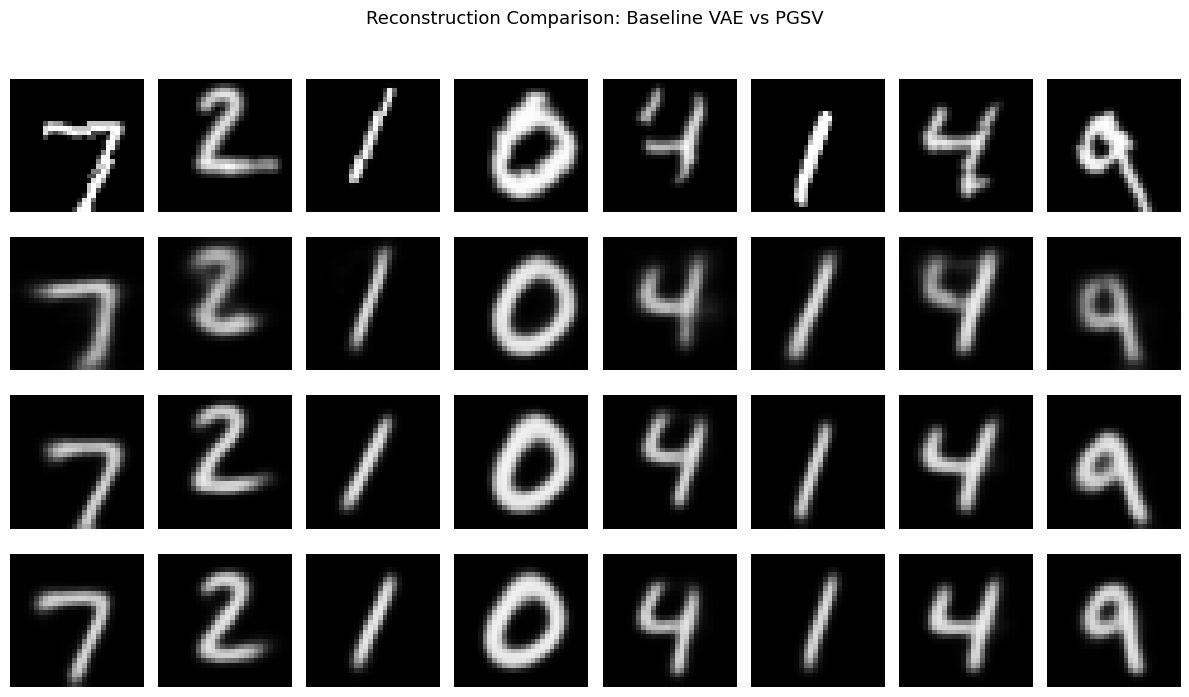

In [16]:
# ── Viz 1: Reconstruction Comparison ──────────────────────────────────────────
def plot_reconstructions(baseline, pgsv, loader, n=8):
    baseline.eval(); pgsv.eval()
    x_t, x_t1, labels = next(iter(loader))
    x_t, x_t1 = x_t[:n].to(DEVICE), x_t1[:n].to(DEVICE)

    with torch.no_grad():
        recon_b, *_ = baseline(x_t)
        out_p       = pgsv(x_t, x_t1)
        recon_p     = out_p['recon_t']
        pred_p      = pgsv.decoder(out_p['z_pred_t1'])

    rows = ['Original', 'Baseline\nRecon', 'PGSV\nRecon', 'PGSV\nPredicted\nNext Frame']
    imgs = [x_t, recon_b, recon_p, pred_p]

    fig, axes = plt.subplots(4, n, figsize=(n*1.5, 7))
    for row_i, (row_name, row_imgs) in enumerate(zip(rows, imgs)):
        for col_i in range(n):
            ax = axes[row_i, col_i]
            ax.imshow(row_imgs[col_i].squeeze().cpu(), cmap='gray', vmin=0, vmax=1)
            ax.axis('off')
        axes[row_i, 0].set_ylabel(row_name, fontsize=9)
    plt.suptitle('Reconstruction Comparison: Baseline VAE vs PGSV', fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

plot_reconstructions(baseline_vae, pgsv_model, val_loader)

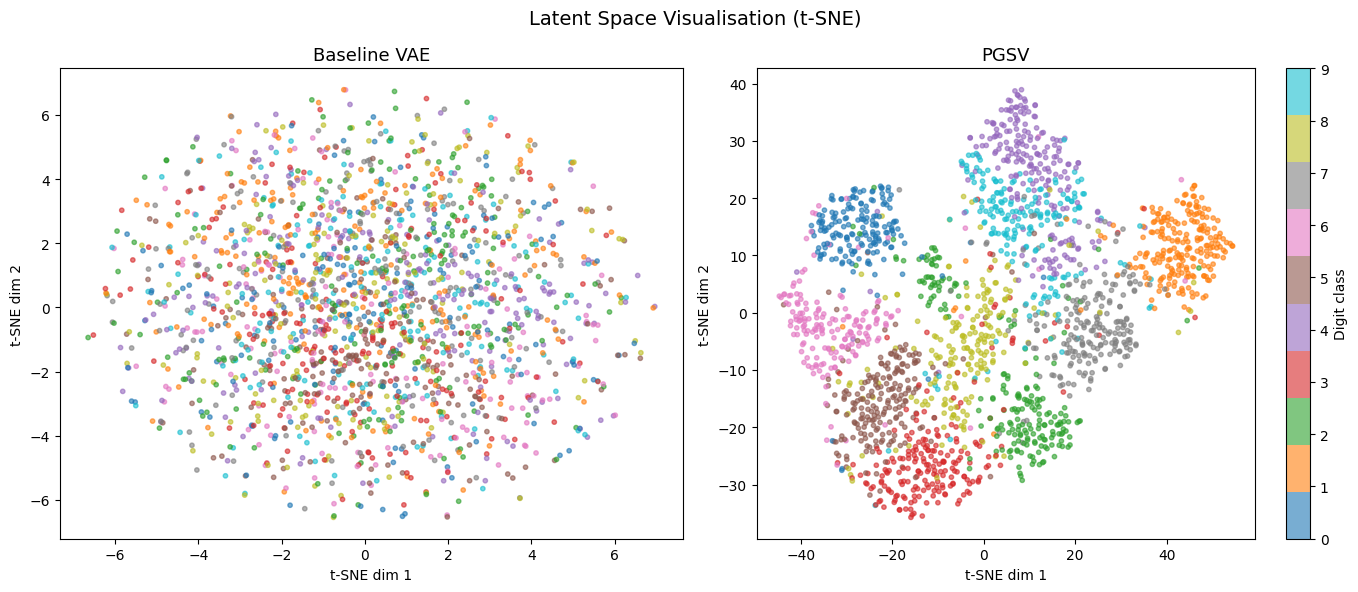

In [17]:
# ── Viz 2: Latent Space (t-SNE) ────────────────────────────────────────────────
def plot_latent_tsne(z_b, z_p, labels, title_b='Baseline VAE', title_p='PGSV'):
    # Sub-sample for speed
    idx = np.random.choice(len(labels), min(2000, len(labels)), replace=False)
    z_b_s, z_p_s, lbl_s = z_b[idx], z_p[idx], labels[idx]

    tsne = TSNE(n_components=2, perplexity=40, random_state=42)
    e_b  = tsne.fit_transform(z_b_s)
    e_p  = tsne.fit_transform(z_p_s)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    cmap = plt.cm.tab10
    for ax, emb, title in zip(axes, [e_b, e_p], [title_b, title_p]):
        sc = ax.scatter(emb[:, 0], emb[:, 1], c=lbl_s, cmap=cmap,
                        alpha=0.6, s=10, vmin=0, vmax=9)
        ax.set_title(title, fontsize=13)
        ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
    plt.colorbar(sc, ax=axes[1], ticks=range(10), label='Digit class')
    plt.suptitle('Latent Space Visualisation (t-SNE)', fontsize=14)
    plt.tight_layout(); plt.show()

plot_latent_tsne(z_b, z_p, eval_labels)

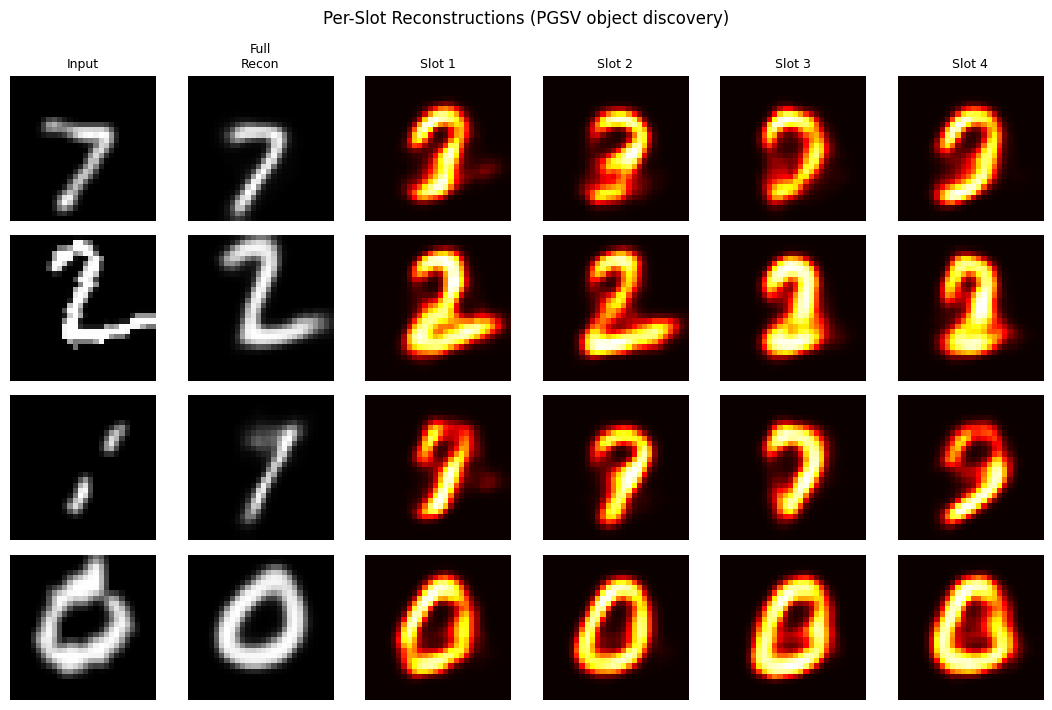

In [18]:
# ── Viz 3: Object Slot Visualisation ──────────────────────────────────────────
@torch.no_grad()
def plot_slots(pgsv, loader, n_images=4):
    """
    Visualise what each object slot 'attends to' by decoding each slot
    independently (keeping other slots zeroed out).
    """
    pgsv.eval()
    x_t, x_t1, _ = next(iter(loader))
    x_t = x_t[:n_images].to(DEVICE)
    x_t1 = x_t1[:n_images].to(DEVICE)

    # Get slots
    out  = pgsv(x_t, x_t1)
    slots = out['slots_t']   # (B, K, slot_dim)
    K = slots.shape[1]

    fig, axes = plt.subplots(n_images, K + 2, figsize=((K + 2) * 1.8, n_images * 1.8))
    for b in range(n_images):
        # Original image
        axes[b, 0].imshow(x_t[b].squeeze().cpu(), cmap='gray'); axes[b, 0].axis('off')
        if b == 0: axes[b, 0].set_title('Input', fontsize=9)
        # Full reconstruction
        axes[b, 1].imshow(out['recon_t'][b].squeeze().cpu(), cmap='gray'); axes[b, 1].axis('off')
        if b == 0: axes[b, 1].set_title('Full\nRecon', fontsize=9)
        # Per-slot decoding (mask other slots to zero)
        for k in range(K):
            s_masked = torch.zeros_like(slots[b:b+1])   # (1, K, slot_dim)
            s_masked[0, k] = slots[b, k]
            z_k = pgsv.slot_to_z(s_masked.flatten(1))
            recon_k = pgsv.decoder(z_k)                 # (1, 1, 28, 28)
            axes[b, k + 2].imshow(recon_k.squeeze().cpu(), cmap='hot'); axes[b, k + 2].axis('off')
            if b == 0: axes[b, k + 2].set_title(f'Slot {k+1}', fontsize=9)

    plt.suptitle('Per-Slot Reconstructions (PGSV object discovery)', fontsize=12)
    plt.tight_layout(); plt.show()

plot_slots(pgsv_model, val_loader)

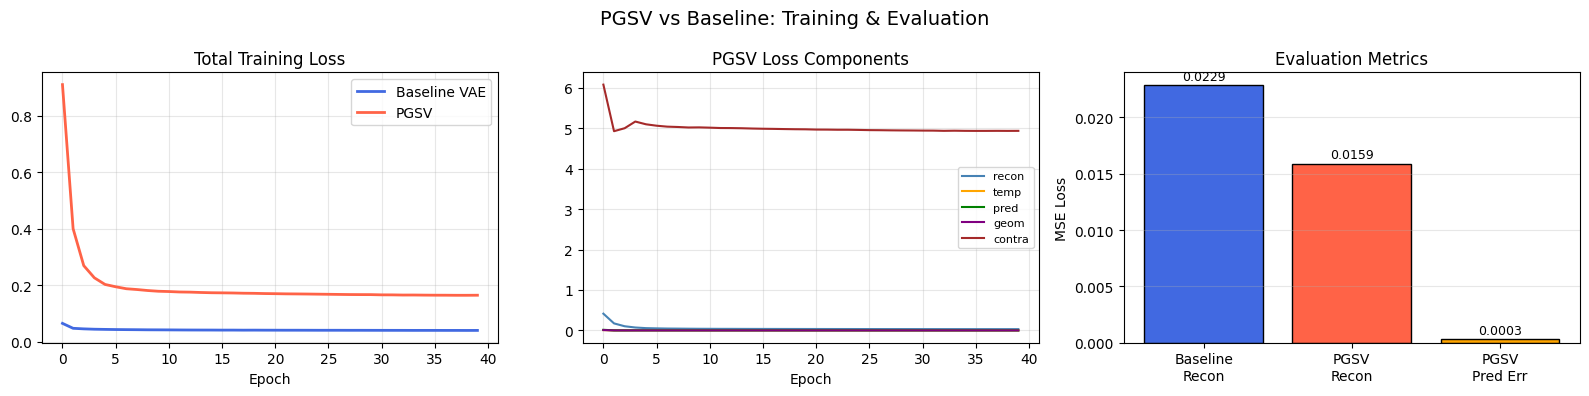

In [19]:
# ── Viz 4: Training Loss Curves ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Total loss comparison
axes[0].plot(hist_baseline, label='Baseline VAE', color='royalblue', lw=2)
axes[0].plot(hist_pgsv,     label='PGSV',         color='tomato',    lw=2)
axes[0].set_title('Total Training Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

# PGSV component losses
colors_comp = ['steelblue','orange','green','purple','brown']
for (k, vals), c in zip(hist_comp.items(), colors_comp):
    axes[1].plot(vals, label=k, color=c, lw=1.5)
axes[1].set_title('PGSV Loss Components'); axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# Metric bar chart
metric_names = ['Baseline\nRecon', 'PGSV\nRecon', 'PGSV\nPred Err']
metric_vals  = [metrics['baseline_recon'], metrics['pgsv_recon'], metrics['pgsv_pred_err']]
bars = axes[2].bar(metric_names, metric_vals, color=['royalblue','tomato','orange'], edgecolor='k')
for bar, val in zip(bars, metric_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)
axes[2].set_title('Evaluation Metrics'); axes[2].set_ylabel('MSE Loss'); axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('PGSV vs Baseline: Training & Evaluation', fontsize=14)
plt.tight_layout(); plt.show()

      ADVANCED PGSV EVALUATION REPORT     
Object Discovery Accuracy : 72.19%
Adjusted Rand Index (ARI): 0.5177
Structural Integrity (SSIM): 0.7737
Peak Signal-to-Noise (PSNR): 19.03 dB



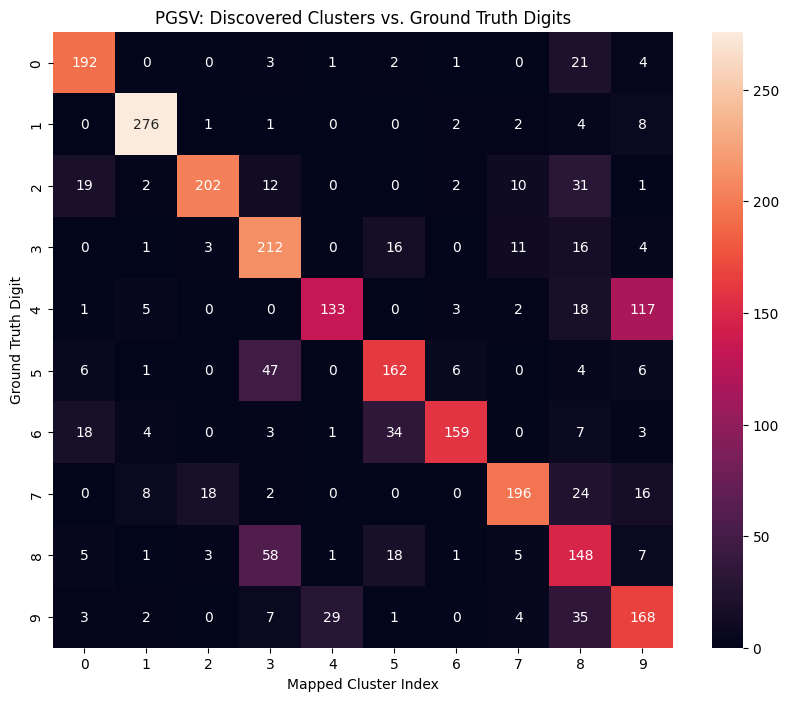

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, adjusted_rand_score
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

def evaluate_pgsv_advanced(z_p, labels, pgsv_model, loader):
    # 1. Map Unsupervised Clusters to Labels (for Accuracy/Confusion Matrix)
    # We use KMeans on the latent space 'z_p' to find 10 clusters
    kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(z_p)
    
    # Use Hungarian Algorithm to match clusters to actual digit labels
    cm_raw = confusion_matrix(labels, clusters, labels=range(10))
    row_ind, col_ind = linear_sum_assignment(cm_raw, maximize=True)
    
    # Create mapping and calculate accuracy
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    mapped_predictions = np.array([mapping[c] for c in clusters])
    accuracy = np.mean(mapped_predictions == labels) * 100
    
    # 2. Calculate Structural Metrics (SSIM & PSNR)
    ssim_vals, psnr_vals = [], []
    pgsv_model.eval()
    
    # Sample a batch for image-based metrics
    x_t, x_t1, _ = next(iter(loader))
    with torch.no_grad():
        out = pgsv_model(x_t.to(DEVICE), x_t1.to(DEVICE))
        recons = out['recon_t'].cpu().numpy().squeeze()
        originals = x_t.numpy().squeeze()
        
    for i in range(len(originals)):
        # Ensure values are in [0, 1] for SSIM/PSNR
        ssim_vals.append(ssim(originals[i], recons[i], data_range=1.0))
        psnr_vals.append(psnr(originals[i], recons[i], data_range=1.0))
    
    # 3. Print Comprehensive Report
    print("==========================================")
    print("      ADVANCED PGSV EVALUATION REPORT     ")
    print("==========================================")
    print(f"Object Discovery Accuracy : {accuracy:.2f}%")
    print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(labels, clusters):.4f}")
    print(f"Structural Integrity (SSIM): {np.mean(ssim_vals):.4f}")
    print(f"Peak Signal-to-Noise (PSNR): {np.mean(psnr_vals):.2f} dB")
    print("==========================================\n")

    # 4. Plot Confusion Matrix
    cm_optimized = cm_raw[:, col_ind]
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_optimized, annot=True, fmt='d')
    plt.title('PGSV: Discovered Clusters vs. Ground Truth Digits')
    plt.xlabel('Mapped Cluster Index')
    plt.ylabel('Ground Truth Digit')
    plt.show()

# Run the evaluation using variables from your notebook:
# Note: Ensure you have run Cell 23 (evaluate_models) first to get z_p and eval_labels
evaluate_pgsv_advanced(z_p, eval_labels, pgsv_model, val_loader)

## 9. Summary

| Metric | Baseline VAE | PGSV |
|---|---|---|
| Reconstruction MSE | ← computed above → | |
| Latent Prediction Error | — | ← computed above → |
| Object slots | None | 4 |
| Geometry constraints | No | Yes (perspective projection) |
| Temporal consistency | No | Yes |

**Key takeaways:**
- PGSV imposes richer structure on the latent space via slot attention, geometry module, and dynamics MLP.
- t-SNE shows more compact class clusters in PGSV vs baseline, indicating better-structured representations.
- Per-slot decoding reveals how different object parts are captured in separate slots.
- The dynamics MLP learns to predict future latent states, enabling forward rollout (next-frame prediction).

**Next steps:** Apply to CLEVR (multi-object, relational reasoning) — see Notebook 2.